In [1]:
import edes 
from edes.utils.plotting import plot, plot_ax, big_plt_font, plot_ax_errbar, plot_errbar
from edes.utils.plotting import plot_generated_timelines, generate_signal_timeline
from edes.utils.circuits import dBm_to_W, W_to_dBm
from edes.utils.utils import U2_to_MHz
from edes.utils.file_handling import load_h5_data, load_latest_data, load_latest_filename, list_filenames, convert_dict_to_dataframe
from edes.utils.file_handling import list_filepaths, list_files_in_time_range
from edes.experiments.analysis.lock_in_detection import plot_individual_PvT, plot_hist, compare_hist_U2_Ex_continuous_loading, \
                                                        plot_Prob_vs_var, compare_PvT_U2_Ex_continuous_loading, plot_PvT_across_var, \
                                                        plot_hist_across_var, plot_peak_power_vs_var
import numpy as np 
from tqdm import tqdm, trange 
import matplotlib.pyplot as plt 
import time
import datetime
import pandas as pd

import json
import os
import re
big_plt_font()

In [2]:
home_dir = '/home/electron/'
data_dir = home_dir + f'artiq/experiment/artiq-master/results/{datetime.datetime.now().strftime("%Y-%m-%d")}'
results_base_dir = os.path.join(home_dir, 'artiq/experiment/artiq-master/results/')

In [3]:
def load_artiq_h5_arguments(filename, arg, base=''):
    return json.loads(load_h5_data(filename, base=base)['expid'])['arguments'][arg]

In [4]:
def find_file_by_rid(rid, search_dir, base_dir_to_strip):
    """Searches for an ARTIQ .h5 file matching the given RID."""
    target_prefix = f"{int(rid):09d}-"
    for root, dirs, files in os.walk(search_dir):
        for file in files:
            if file.startswith(target_prefix) and file.endswith('.h5'):
                full_path = os.path.join(root, file)
                # Strip the home_dir from the start so load_h5_data works correctly with base=home_dir
                if full_path.startswith(base_dir_to_strip):
                    return full_path[len(base_dir_to_strip):]
                return full_path
    return None


Processing With FB, outside box from artiq/experiment/artiq-master/results/2026-08-18/10/000010914-FeedbackWithSingleConfig.h5
Processing With FB, inside box from artiq/experiment/artiq-master/results/2026-08-18/14/000010958-FeedbackWithSingleConfig.h5
Processing Without FB from artiq/experiment/artiq-master/results/2026-08-18/14/000010960-FeedbackWithSingleConfig.h5


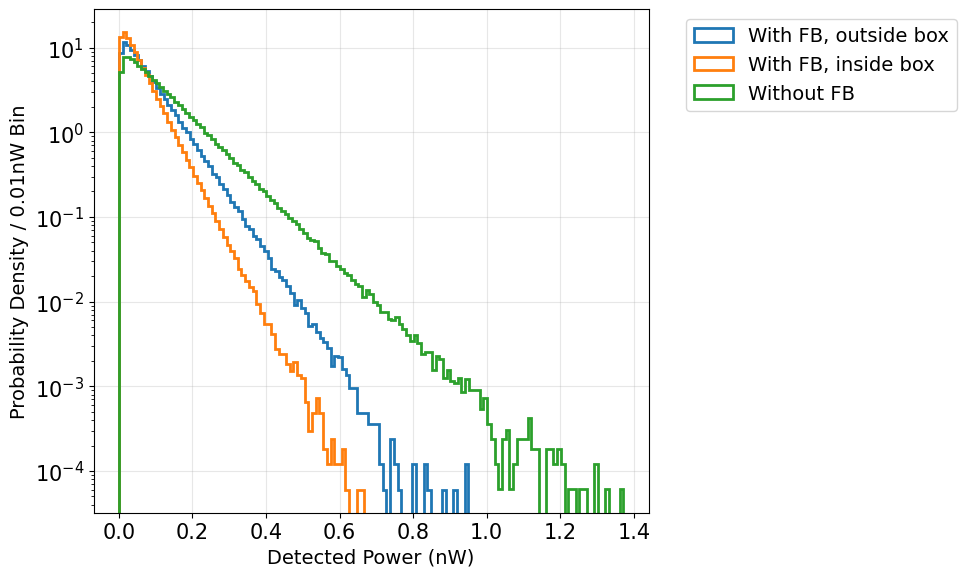

In [8]:
N_data_SWT = 751

# 1. Define your RIDs here. Use (RID, "Label") for custom names, or just RID for default.
rids_to_plot = [
    (10914, "With FB, outside box"),
    (10958, "With FB, inside box"),
    (10960, "Without FB")
]

plt.figure(figsize=(10, 6))

# 2. Loop through the list
for item in rids_to_plot:
    # Check if the item is a tuple (has a custom label) or just an integer
    if isinstance(item, tuple):
        rid, label = item
    else:
        rid, label = item, f"RID {item}"
        
    filename = find_file_by_rid(rid, results_base_dir, home_dir)
    
    if not filename:
        print(f"Could not find file for RID: {rid}. Skipping.")
        continue
        
    print(f"Processing {label} from {filename}")
    
    file = load_h5_data(filename, base=home_dir)['datasets']
    SWT = load_artiq_h5_arguments(filename, 'SSA_SWT', base=home_dir)
    
    all_powers = []
    for i in file: 
        if i[:8] == 'all_meas': 
            powers = file[i] 
            if len(powers) > 0:
                index = int(i[9:]) 
                time_stamp = file[f'time_stamps_{index}']
                for j in range(len(time_stamp)): 
                    all_powers.extend(powers[j])
            
    if len(all_powers) == 0:
        print(f"No power data found in {label}. Skipping.")
        continue

    # Process powers
    P_nW = dBm_to_W(np.array(all_powers).flatten()) * 1e9
    
    # Calculate bins
    num_bins = int((max(P_nW) - min(P_nW)) / 0.01)
    
    # Get the next color from matplotlib's color cycle
    color = plt.gca()._get_lines.get_next_color()
    
    # Plot the histogram using the resolved label
    plt.hist(P_nW, bins=num_bins, density=True, histtype='step', linewidth=2, 
             color=color, label=label)

# Final plot formatting
plt.xlabel('Detected Power (nW)') 
plt.ylabel('Probability Density / 0.01nW Bin')
plt.grid(True, alpha=0.3)
plt.yscale('log')

# Move legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.show()

In [13]:
file.keys()

dict_keys(['FET.all_I', 'FET.all_I_std', 'FET.all_V', 'Progress_index', 'SSA_power', 'all_meas_0', 'all_meas_1', 'all_meas_2', 'all_meas_3', 'all_meas_4', 'all_meas_5', 'all_meas_6', 'all_meas_7', 'all_meas_8', 'all_meas_9', 'main_sequence.e.bl1', 'main_sequence.e.bl2', 'main_sequence.e.bl3', 'main_sequence.e.bl4', 'main_sequence.e.bl5', 'main_sequence.e.br1', 'main_sequence.e.br2', 'main_sequence.e.br3', 'main_sequence.e.br4', 'main_sequence.e.br5', 'main_sequence.e.tl1', 'main_sequence.e.tl2', 'main_sequence.e.tl3', 'main_sequence.e.tl4', 'main_sequence.e.tl5', 'main_sequence.e.tr1', 'main_sequence.e.tr2', 'main_sequence.e.tr3', 'main_sequence.e.tr4', 'main_sequence.e.tr5', 'main_sequence.multipole.Ex', 'main_sequence.multipole.Ey', 'main_sequence.multipole.Ez', 'main_sequence.multipole.U1', 'main_sequence.multipole.U2', 'main_sequence.multipole.U3', 'main_sequence.multipole.U4', 'main_sequence.multipole.U5', 'rid', 't_data', 'time_stamps_0', 'time_stamps_1', 'time_stamps_2', 'time_s

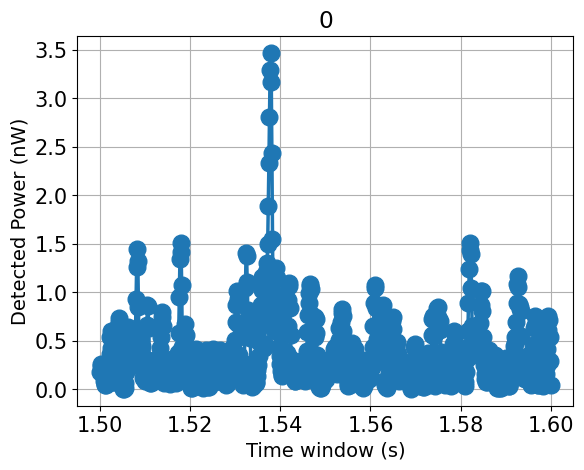

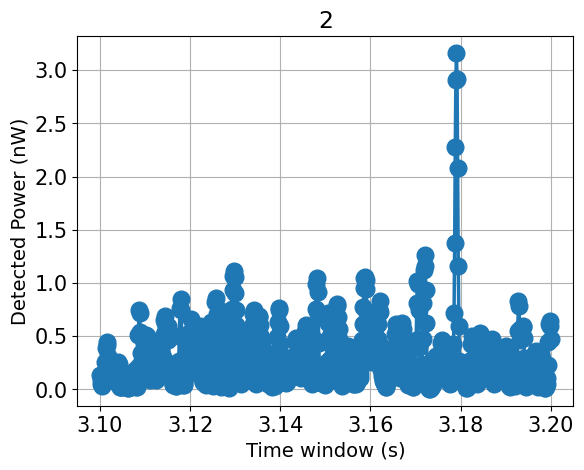

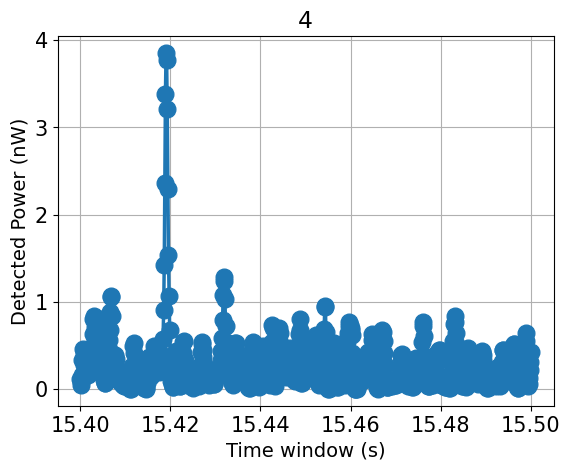

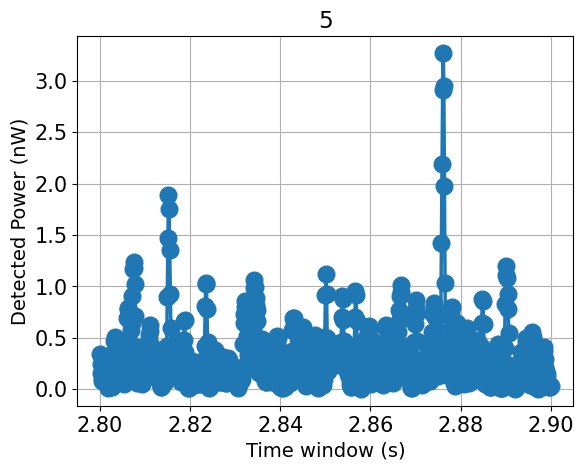

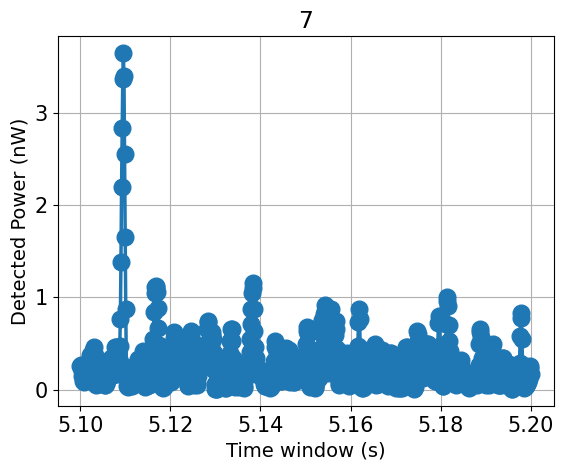

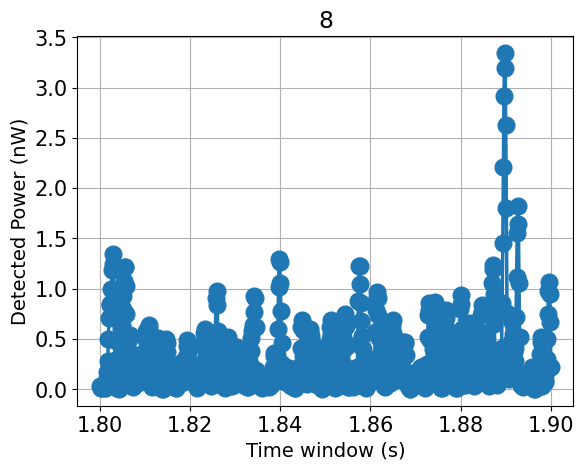

In [19]:

N_data_SWT = 751
filename = 'artiq/experiment/artiq-master/results/2026-08-10/16/000010836-FeedbackWithSingleConfig.h5'
file = load_h5_data(filename, base=home_dir)['datasets']
SWT = load_artiq_h5_arguments(filename, 'SSA_SWT', base=home_dir)
all_powers = []
for i in file: 
    # print(i[:9])
    if i[:8] == 'all_meas': 
        powers = file[i] 
        if len(powers) > 0:
            index = int(i[9:]) 
            time_stamp = file[f'time_stamps_{index}']
            for j in range(len(time_stamp)): 
                t_ax = np.linspace(time_stamp[j], time_stamp[j]+SWT, N_data_SWT)
                plot(t_ax, 10**(powers[j]/10)*1e6, xlabel='Time window (s)', ylabel='Detected Power (nW)', marker = 'o', title = f"{i[9]}")
                all_powers.extend(powers[j])
                # plt.xlim(3.90,3.92)
            plt.show()
        

In [20]:

N_data_SWT = 751
filename = 'artiq/experiment/artiq-master/results/2026-08-10/16/000010837-FeedbackWithSingleConfig.h5'
file = load_h5_data(filename, base=home_dir)['datasets']
SWT = load_artiq_h5_arguments(filename, 'SSA_SWT', base=home_dir)
all_powers = []
for i in file: 
    # print(i[:9])
    if i[:8] == 'all_meas': 
        powers = file[i] 
        if len(powers) > 0:
            index = int(i[9:]) 
            time_stamp = file[f'time_stamps_{index}']
            for j in range(len(time_stamp)): 
                t_ax = np.linspace(time_stamp[j], time_stamp[j]+SWT, N_data_SWT)
                # plot(t_ax, 10**(powers[j]/10)*1e6, xlabel='Time window (s)', ylabel='Detected Power (nW)', marker = 'o')
                all_powers.extend(powers[j])
                # plt.xlim(3.90,3.92)
            # plt.show()
        

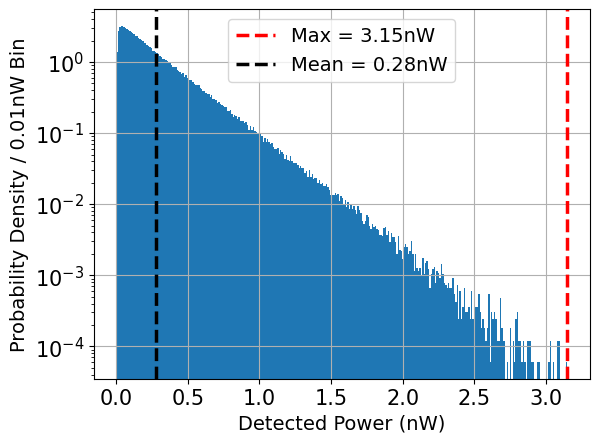

In [21]:
P_nW = dBm_to_W(np.array(all_powers).flatten())*1e9
plt.hist(P_nW, bins=int((max(P_nW)-min(P_nW))/0.01), density=True)
plt.axvline(max(P_nW), linestyle='--', c='r', label=f'Max = {max(P_nW):.2f}nW')
plt.axvline(np.mean(P_nW), linestyle='--', c='k', label=f'Mean = {np.mean(P_nW):.2f}nW')
plt.xlabel('Detected Power (nW)') 
plt.ylabel('Probability Density / 0.01nW Bin')
plt.grid()
plt.yscale('log')
plt.legend()
plt.show()

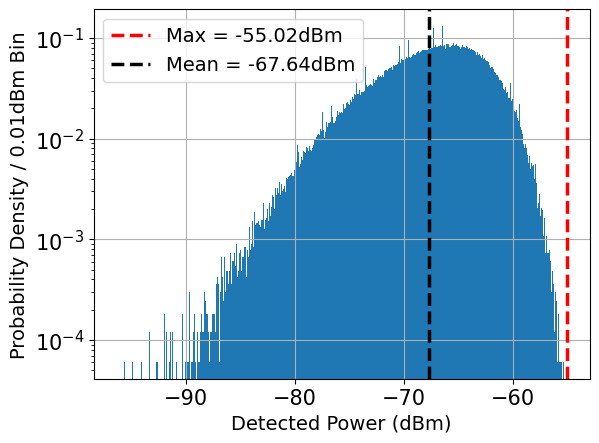

In [22]:
P_dBm = np.array(all_powers).flatten()
plt.hist(P_dBm, bins=int((max(P_dBm)-min(P_dBm))/0.01), density=True)
plt.axvline(max(P_dBm), linestyle='--', c='r', label=f'Max = {max(P_dBm):.2f}dBm')
plt.axvline(np.mean(P_dBm), linestyle='--', c='k', label=f'Mean = {np.mean(P_dBm):.2f}dBm')
plt.xlabel('Detected Power (dBm)') 
plt.ylabel('Probability Density / 0.01dBm Bin')
plt.grid()
plt.yscale('log')
plt.legend()
plt.show()

In [48]:
max(all_powers)

-62.9635

In [23]:
import pandas as pd
import numpy as np

def convert_dict_to_dataframe(data_dict, var_names=None):
    """
    Converts an HDF5 data dictionary with keys formatted like 'data.{var1}.{var2}....{varN}'
    or 'data.var1=val1.var2=val2' into a structured pandas DataFrame.

    Parameters
    ----------
    data_dict : dict
        Dictionary loaded from HDF5 file.
    var_names : list of str, optional
        Custom column names for positional variables.

    Returns
    -------
    df : pandas.DataFrame
        DataFrame with dynamic variable columns, 'data', and 'time' (if present).
    """
    # 1. Infer variable names if not explicitly passed
    if var_names is None:
        for meta_key in ['var_names', 'variables', 'param_names']:
            if meta_key in data_dict:
                var_names = list(data_dict[meta_key])
                break

    # 2. Extract shared time/x-axis array if stored at the root
    time_data = None
    for t_key in ['time', 't', 't_axis', 'x_axis']:
        if t_key in data_dict:
            time_data = data_dict[t_key]
            break

    records = []

    # Safe fallback if datasets are at root level vs. nested in 'datasets'
    datasets_source = data_dict.get('datasets', data_dict)

    # Helper function to check if string is numeric (to avoid mis-splitting e.g. "1.5e_2")
    def is_number(s):
        try:
            float(str(s).replace('_', ''))
            return True
        except ValueError:
            return False

    # 3. Parse all dataset keys starting with 'data.' or 'data/'
    for key, value in datasets_source.items():
        if not isinstance(key, str):
            continue

        if key.startswith('data.') or key.startswith('data/'):
            tokens = key.replace('/', '.').split('.')[1:]
            row = {}

            for idx, token in enumerate(tokens):
                # Format A: Key-Value via '=' (e.g. "Ex=10")
                if '=' in token:
                    k, v = token.split('=', 1)
                    row[k] = v

                # Format B: Key-Value via '_' (e.g. "Ex_10"), excluding numeric tokens
                elif '_' in token and not is_number(token):
                    k, v = token.split('_', 1)
                    row[k] = v

                # Format C: Positional Value (e.g. "10")
                else:
                    col_name = var_names[idx] if (var_names and idx < len(var_names)) else f'var{idx + 1}'
                    row[col_name] = token

            # Attach raw signal and time array
            row['data'] = value
            if time_data is not None:
                row['time'] = time_data

            records.append(row)

    df = pd.DataFrame(records)

    # 4. Automatically convert parameter columns to numeric types (Pandas 2.0+ safe)
    for col in df.columns:
        if col not in ['data', 'time']:
            try:
                df[col] = pd.to_numeric(df[col])
            except (ValueError, TypeError):
                pass  # Keep non-numeric strings intact

    return df

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

def compare_sweep_data(data_files, data_dir='', var_names=None, fix_ylim=False):
    """
    Plots interactive curves across dynamically detected variables in HDF5 sweep files,
    with an index control (i) to iterate through sub-arrays / trace batches.
    """
    # 1. Load all files into a single master DataFrame
    df_list = []
    print("Scanning HDF5 datasets...")
    for filepath in data_files:
        try:
            data_dict = load_h5_data(filepath, base=data_dir)
            df = convert_dict_to_dataframe(data_dict, var_names=var_names)
            df['_filepath'] = filepath
            df_list.append(df)
        except Exception as e:
            print(f"Skipping {filepath} due to error: {e}")

    if not df_list:
        print("No valid data loaded.")
        return

    master_df = pd.concat(df_list, ignore_index=True)

    # Identify parameter columns (excluding internal/data/time columns)
    param_cols = [c for c in master_df.columns if c not in ['data', 'time', '_filepath']]
    print(f"Scan complete. Recognized variables: {param_cols}")

    # Calculate global y-limits across all sub-arrays
    global_y_min, global_y_max = float('inf'), float('-inf')
    for raw_data in master_df['data'].values:
        y_arr = np.array(raw_data)
        if y_arr.size > 0:
            global_y_min = min(global_y_min, np.min(y_arr))
            global_y_max = max(global_y_max, np.max(y_arr))

    has_global_limits = (global_y_min != float('inf') and global_y_max != float('-inf'))
    if has_global_limits:
        y_range = global_y_max - global_y_min
        padding = y_range * 0.05 if y_range > 0 else 1.0
        global_y_min -= padding
        global_y_max += padding
    else:
        global_y_min, global_y_max = -100, 10

    # 2. Build UI Dropdowns for Parameter Variables
    var_dropdowns = {}
    for col in param_cols:
        unique_vals = sorted(master_df[col].dropna().unique())
        var_dropdowns[col] = widgets.Dropdown(
            options=unique_vals,
            description=f'{col}:',
            style={'description_width': 'initial'}
        )

    # 3. Trace Index (i) Widgets
    trace_idx_slider = widgets.IntSlider(
        value=0,
        min=0,
        max=29,  # Will adjust dynamically based on array length
        step=1,
        description='Trace (i):',
        continuous_update=False,
        style={'description_width': 'initial'}
    )

    btn_trace_prev = widgets.Button(description='Prev Trace', button_style='info', icon='arrow-left')
    btn_trace_next = widgets.Button(description='Next Trace', button_style='primary', icon='arrow-right')

    fix_ylim_checkbox = widgets.Checkbox(
        value=fix_ylim,
        description='Fix Y-Axis Limits',
        disabled=not has_global_limits,
        indent=False
    )

    plot_output = widgets.Output()

    # 4. Drawing Logic
    def draw_plot(change=None):
        # Filter master_df based on variable dropdown selections
        filtered_df = master_df.copy()
        current_selection = {}
        for col, dropdown in var_dropdowns.items():
            val = dropdown.value
            current_selection[col] = val
            if val is not None:
                if isinstance(val, (int, float, np.number)):
                    filtered_df = filtered_df[np.isclose(filtered_df[col].astype(float), float(val), atol=1e-5)]
                else:
                    filtered_df = filtered_df[filtered_df[col] == val]

        with plot_output:
            clear_output(wait=True)
            if filtered_df.empty:
                print(f"No configuration found matching: {current_selection}")
                return

            row = filtered_df.iloc[0]
            raw_data = np.array(row['data'])

            # Multi-trace array indexing check
            if raw_data.ndim > 1:
                num_traces = raw_data.shape[0]
                # Update slider upper bound dynamically
                if trace_idx_slider.max != num_traces - 1:
                    trace_idx_slider.max = max(0, num_traces - 1)

                i = min(trace_idx_slider.value, num_traces - 1)
                y_data = raw_data[i]
                trace_info = f" | Trace i = {i}/{num_traces - 1}"
            else:
                y_data = raw_data
                trace_info = ""

            # Extract time/x-axis vector
            if 'time' in row and row['time'] is not None:
                t_data = np.array(row['time'])
                t_axis = t_data[i] if (t_data.ndim > 1 and t_data.shape[0] == raw_data.shape[0]) else t_data
            else:
                t_axis = np.arange(len(y_data))

            # Plotting
            fig, ax = plt.subplots(figsize=(8, 4))
            ax.plot(t_axis, y_data, color='blue', lw=2)

            if fix_ylim_checkbox.value:
                ax.set_ylim(global_y_min, global_y_max)

            title_params = " | ".join([f"{k}: {v}" for k, v in current_selection.items()])
            ax.set_title(f"{title_params}{trace_info}")
            ax.set_xlabel("Time / Index")
            ax.set_ylabel("Signal")
            ax.grid(True)
            plt.show()

    # 5. Trace Navigation Buttons
    def on_prev_trace(b):
        if trace_idx_slider.value > trace_idx_slider.min:
            trace_idx_slider.value -= 1

    def on_next_trace(b):
        if trace_idx_slider.value < trace_idx_slider.max:
            trace_idx_slider.value += 1

    # 6. Bind Observers & Handlers
    for dd in var_dropdowns.values():
        dd.observe(draw_plot, names='value')
        
    trace_idx_slider.observe(draw_plot, names='value')
    fix_ylim_checkbox.observe(lambda c: draw_plot(), names='value')

    btn_trace_prev.on_click(on_prev_trace)
    btn_trace_next.on_click(on_next_trace)

    # 7. Layout Assembly
    dropdown_widgets = list(var_dropdowns.values())
    param_controls = widgets.HBox(dropdown_widgets)
    trace_controls = widgets.HBox([btn_trace_prev, trace_idx_slider, btn_trace_next, fix_ylim_checkbox])

    ui = widgets.VBox([
        param_controls,
        trace_controls,
        plot_output
    ])

    display(ui)
    draw_plot()

In [26]:
import pandas as pd
import numpy as np

def parse_encoded_number(val):
    """
    Cleans sweep string numbers like '_-0p4' or '_-0p09999999999999998' 
    into clean floats like -0.4 and -0.1.
    """
    if not isinstance(val, str):
        return val

    # Strip leading/trailing underscores and whitespace
    s = val.strip().strip('_')
    
    # Replace decimal 'p' or 'P' with '.'
    candidate = s.replace('p', '.').replace('P', '.')

    try:
        num = float(candidate)
        # Round to eliminate float representation artifacts (e.g. -0.09999999999999998 -> -0.1)
        num = round(num, 6)
        return 0.0 if num == 0.0 else num
    except ValueError:
        return val  # Return original if non-numeric string


def convert_dict_to_dataframe(data_dict, var_names=None):
    """
    Converts an HDF5 data dictionary with keys formatted like 'data.Ex_-0p1.Ey_-0p4'
    or 'data.Ex=_-0p1.Ey=_-0p4' into a structured pandas DataFrame.
    """
    # 1. Infer variable names if not explicitly passed
    if var_names is None:
        for meta_key in ['var_names', 'variables', 'param_names']:
            if meta_key in data_dict:
                var_names = list(data_dict[meta_key])
                break

    # 2. Extract shared time/x-axis array if stored at the root
    time_data = None
    for t_key in ['time', 't', 't_axis', 'x_axis']:
        if t_key in data_dict:
            time_data = data_dict[t_key]
            break

    records = []
    datasets_source = data_dict.get('datasets', data_dict)

    # 3. Parse dataset keys
    for key, value in datasets_source.items():
        if not isinstance(key, str):
            continue

        if key.startswith('data.') or key.startswith('data/'):
            tokens = key.replace('/', '.').split('.')[1:]
            row = {}

            for idx, token in enumerate(tokens):
                # Format A: Key-Value via '=' (e.g. "Ex=_-0p4")
                if '=' in token:
                    k, v = token.split('=', 1)
                    row[k] = parse_encoded_number(v)

                # Format B: Key-Value via '_' (e.g. "Ex_-0p4")
                elif '_' in token:
                    # Split only on first underscore to separate var_name from encoded value
                    parts = token.split('_', 1)
                    parsed_val = parse_encoded_number(parts[1])
                    
                    # If part 2 parsed as numeric, treat part 1 as column name
                    if isinstance(parsed_val, (int, float)):
                        row[parts[0]] = parsed_val
                    else:
                        col_name = var_names[idx] if (var_names and idx < len(var_names)) else f'var{idx + 1}'
                        row[col_name] = parse_encoded_number(token)

                # Format C: Positional value (e.g. "_-0p4")
                else:
                    col_name = var_names[idx] if (var_names and idx < len(var_names)) else f'var{idx + 1}'
                    row[col_name] = parse_encoded_number(token)

            row['data'] = value
            if time_data is not None:
                row['time'] = time_data

            records.append(row)

    df = pd.DataFrame(records)

    # 4. Final attempt to convert remaining string columns to numeric
    for col in df.columns:
        if col not in ['data', 'time']:
            try:
                df[col] = pd.to_numeric(df[col].apply(parse_encoded_number))
            except (ValueError, TypeError):
                pass

    return df

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import ipywidgets as widgets
from IPython.display import display, clear_output

def parse_encoded_number(val):
    """Parses encoded parameter strings (e.g., '_-0p4') into clean floats."""
    if not isinstance(val, str):
        if isinstance(val, (float, np.floating)):
            return round(float(val), 6)
        return val

    s = val.strip().strip('_')
    candidate = s.replace('p', '.').replace('P', '.')

    try:
        num = float(candidate)
        num = round(num, 6)
        return 0.0 if num == 0.0 else num
    except ValueError:
        return val


def convert_dict_to_dataframe(data_dict, var_names=None):
    """Converts HDF5 data dictionary into a pandas DataFrame."""
    if var_names is None:
        for meta_key in ['var_names', 'variables', 'param_names']:
            if meta_key in data_dict:
                var_names = list(data_dict[meta_key])
                break

    time_data = None
    for t_key in ['time', 't', 't_axis', 'x_axis']:
        if t_key in data_dict:
            time_data = data_dict[t_key]
            break

    records = []
    datasets_source = data_dict.get('datasets', data_dict)

    for key, value in datasets_source.items():
        if not isinstance(key, str):
            continue

        if key.startswith('data.') or key.startswith('data/'):
            tokens = key.replace('/', '.').split('.')[1:]
            row = {}

            for idx, token in enumerate(tokens):
                if '=' in token:
                    k, v = token.split('=', 1)
                    row[k] = parse_encoded_number(v)
                elif '_' in token:
                    parts = token.split('_', 1)
                    parsed_val = parse_encoded_number(parts[1])
                    if isinstance(parsed_val, (int, float)):
                        row[parts[0]] = parsed_val
                    else:
                        col_name = var_names[idx] if (var_names and idx < len(var_names)) else f'var{idx + 1}'
                        row[col_name] = parse_encoded_number(token)
                else:
                    col_name = var_names[idx] if (var_names and idx < len(var_names)) else f'var{idx + 1}'
                    row[col_name] = parse_encoded_number(token)

            row['data'] = value
            if time_data is not None:
                row['time'] = time_data

            records.append(row)

    df = pd.DataFrame(records)

    for col in df.columns:
        if col not in ['data', 'time']:
            try:
                df[col] = pd.to_numeric(df[col].apply(parse_encoded_number))
            except (ValueError, TypeError):
                pass

    return df


def compare_sweep_data(data_files, data_dir='', var_names=None, fix_ylim=False):
    """
    Plots interactive curves, sensitivity comparisons, and parallel coordinates 
    across dynamically detected variables in HDF5 sweep files.
    """
    # 1. Load data
    df_list = []
    print("Scanning HDF5 datasets...")
    for filepath in data_files:
        try:
            data_dict = load_h5_data(filepath, base=data_dir)
            df = convert_dict_to_dataframe(data_dict, var_names=var_names)
            df['_filepath'] = filepath
            df_list.append(df)
        except Exception as e:
            print(f"Skipping {filepath} due to error: {e}")

    if not df_list:
        print("No valid data loaded.")
        return

    master_df = pd.concat(df_list, ignore_index=True)

    param_cols = [c for c in master_df.columns if c not in ['data', 'time', '_filepath', 'trace_maxes', 'overall_max']]
    print(f"Scan complete. Recognized variables: {param_cols}")

    # 2. Compute trace maxes & overall maxes
    def compute_maxes(row):
        arr = np.array(row['data'])
        if arr.size == 0:
            return np.array([]), np.nan
        if arr.ndim > 1:
            t_maxes = np.max(arr, axis=tuple(range(1, arr.ndim)))
        else:
            t_maxes = np.array([np.max(arr)])
        return t_maxes, np.max(t_maxes)

    master_df['trace_maxes'], master_df['overall_max'] = zip(*master_df.apply(compute_maxes, axis=1))

    # Compute global y-limits
    global_y_min, global_y_max = float('inf'), float('-inf')
    for raw_data in master_df['data'].values:
        y_arr = np.array(raw_data)
        if y_arr.size > 0:
            global_y_min = min(global_y_min, np.min(y_arr))
            global_y_max = max(global_y_max, np.max(y_arr))

    has_global_limits = (global_y_min != float('inf') and global_y_max != float('-inf'))
    if has_global_limits:
        y_range = global_y_max - global_y_min
        padding = y_range * 0.05 if y_range > 0 else 1.0
        global_y_min -= padding
        global_y_max += padding
    else:
        global_y_min, global_y_max = -100, 10

    def fmt_val(v):
        if isinstance(v, (float, np.floating)):
            return f"{v:.4g}"
        return str(v)

    # 3. Mode Toggle & Widgets
    view_toggle = widgets.ToggleButtons(
        options=[
            ('Parallel Coordinates', 'parallel_coords'),
            ('All Configs Max Summary', 'all_configs'),
            ('Max vs. Parameter Variable', 'param_vs_max'),
            ('Single Config Inspector', 'single_config')
        ],
        description='View:',
        style={'button_width': 'initial'}
    )

    # Color Normalization Mode Toggle (Fixes Clustered Data Color Compression)
    color_mode_dropdown = widgets.Dropdown(
        options=[('Rank / Percentile (Equalized Contrast)', 'rank'), ('Linear Magnitude', 'linear')],
        value='rank',
        description='Color Scale:',
        style={'description_width': 'initial'}
    )

    if param_cols:
        unique_configs_df = master_df[param_cols].drop_duplicates()
        dropdown_options = [
            (" | ".join([f"{col}: {fmt_val(row[col])}" for col in param_cols]), row.to_dict())
            for _, row in unique_configs_df.iterrows()
        ]
    else:
        dropdown_options = [("All Data", {})]

    config_dropdown = widgets.Dropdown(
        options=dropdown_options,
        description='Config:',
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='800px')
    )

    param_opts = param_cols if param_cols else ['(None)']
    x_param_dropdown = widgets.Dropdown(options=param_opts, description='X Variable:', style={'description_width': 'initial'})
    hue_param_dropdown = widgets.Dropdown(
        options=['None'] + param_opts,
        value='None',
        description='Group/Color By:',
        style={'description_width': 'initial'}
    )

    trace_idx_slider = widgets.IntSlider(
        value=0, min=0, max=29, step=1,
        description='Trace (i):', continuous_update=False,
        style={'description_width': 'initial'}
    )
    btn_trace_prev = widgets.Button(description='Prev Trace', button_style='info', icon='arrow-left')
    btn_trace_next = widgets.Button(description='Next Trace', button_style='primary', icon='arrow-right')

    fix_ylim_checkbox = widgets.Checkbox(
        value=fix_ylim, description='Fix Y-Axis Limits',
        disabled=not has_global_limits, indent=False
    )

    plot_output = widgets.Output()

    # 4. Drawing Logic
    def draw_plot(change=None):
        mode = view_toggle.value
        c_mode = color_mode_dropdown.value

        with plot_output:
            clear_output(wait=True)

            # MODE 1: Interactive Parallel Coordinates
            if mode == 'parallel_coords':
                if not param_cols:
                    print("No parameter variables detected for Parallel Coordinates plot.")
                    return

                cols_to_plot = param_cols + ['overall_max']
                p_df = master_df[cols_to_plot].copy()

                for col in cols_to_plot:
                    p_df[col] = pd.to_numeric(p_df[col], errors='ignore')

                # Create color dimension based on selected mode
                if c_mode == 'rank':
                    p_df['color_val'] = p_df['overall_max'].rank(pct=True)
                    color_title = "Overall Max (Percentile Rank)"
                else:
                    p_df['color_val'] = p_df['overall_max']
                    color_title = "Overall Max (Linear)"

                fig = px.parallel_coordinates(
                    p_df,
                    dimensions=cols_to_plot,
                    color='color_val',
                    color_continuous_scale=px.colors.sequential.Turbo
                )
                fig.update_layout(margin=dict(l=60, r=60, t=60, b=40))
                fig.show()
                return

            # MODES 2-4: Matplotlib-based views
            fig, ax = plt.subplots(figsize=(9.5, 5.5))

            # Calculate normalized color values (0.0 to 1.0) for high-contrast turbo map
            if c_mode == 'rank':
                color_norms = master_df['overall_max'].rank(pct=True).values
            else:
                o_max = master_df['overall_max'].values
                rng = np.ptp(o_max) if np.ptp(o_max) > 0 else 1.0
                color_norms = (o_max - np.min(o_max)) / rng

            cmap = plt.cm.turbo

            if mode == 'all_configs':
                for idx, row in master_df.iterrows():
                    t_maxes = row['trace_maxes']
                    if len(t_maxes) == 0:
                        continue
                    config_label = " | ".join([f"{col}: {fmt_val(row[col])}" for col in param_cols]) if param_cols else "Data"
                    x_axis = np.arange(len(t_maxes))
                    line_color = cmap(color_norms[idx])
                    ax.plot(x_axis, t_maxes, marker='o', label=config_label, color=line_color, lw=1.5, alpha=0.85)

                ax.set_xlabel("Trace Index (i)")
                ax.set_ylabel("Max Signal Value")
                ax.set_title(f"Trace Maximums (Colors: {'Percentile Rank Spread' if c_mode == 'rank' else 'Linear'})")
                ax.grid(True, linestyle='--', alpha=0.6)
                if len(master_df) <= 15:
                    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)

            elif mode == 'param_vs_max':
                x_col = x_param_dropdown.value
                hue_col = hue_param_dropdown.value

                if x_col in master_df.columns:
                    if hue_col != 'None' and hue_col in master_df.columns:
                        groups = master_df.groupby(hue_col)
                        num_groups = max(len(groups), 1)
                        # Distribute group colors using high contrast colormap
                        group_colors = [cmap(i / max(1, num_groups - 1)) for i in range(num_groups)]
                        
                        for (hue_val, group), g_color in zip(groups, group_colors):
                            sorted_grp = group.sort_values(by=x_col)
                            ax.plot(sorted_grp[x_col], sorted_grp['overall_max'], marker='o', label=f"{hue_col}: {fmt_val(hue_val)}", color=g_color, lw=2)
                        ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
                    else:
                        sorted_df = master_df.sort_values(by=x_col)
                        ax.plot(sorted_df[x_col], sorted_df['overall_max'], marker='o', color='darkblue', lw=2)

                    ax.set_xlabel(x_col)
                    ax.set_ylabel("Overall Max Signal")
                    ax.set_title(f"Peak Signal Value vs. {x_col}")
                    ax.grid(True, linestyle='--', alpha=0.6)

            elif mode == 'single_config':
                current_selection = config_dropdown.value or {}
                filtered_df = master_df.copy()
                for col, val in current_selection.items():
                    if val is not None:
                        if isinstance(val, (int, float, np.number)):
                            filtered_df = filtered_df[np.isclose(filtered_df[col].astype(float), float(val), atol=1e-5)]
                        else:
                            filtered_df = filtered_df[filtered_df[col] == val]

                if filtered_df.empty:
                    print(f"No configuration found matching: {current_selection}")
                    plt.close(fig)
                    return

                row = filtered_df.iloc[0]
                raw_data = np.array(row['data'])

                if raw_data.ndim > 1:
                    num_traces = raw_data.shape[0]
                    if trace_idx_slider.max != num_traces - 1:
                        trace_idx_slider.max = max(0, num_traces - 1)

                    i = min(trace_idx_slider.value, num_traces - 1)
                    y_data = raw_data[i]
                    trace_info = f" | Trace i = {i}/{num_traces - 1}"
                else:
                    y_data = raw_data
                    trace_info = ""

                if 'time' in row and row['time'] is not None:
                    t_data = np.array(row['time'])
                    t_axis = t_data[i] if (t_data.ndim > 1 and t_data.shape[0] == raw_data.shape[0]) else t_data
                else:
                    t_axis = np.arange(len(y_data))

                ax.plot(t_axis, y_data, color='#1f77b4', lw=2)
                title_params = " | ".join([f"{k}: {fmt_val(v)}" for k, v in current_selection.items()])
                ax.set_title(f"{title_params}{trace_info}")
                ax.set_xlabel("Time / Index")
                ax.set_ylabel("Signal")
                ax.grid(True, linestyle='--', alpha=0.6)

            if fix_ylim_checkbox.value:
                ax.set_ylim(global_y_min, global_y_max)

            plt.tight_layout()
            plt.show()

    # 5. UI Visibility Control
    def update_ui_visibility(change=None):
        mode = view_toggle.value
        single_cfg_box.layout.display = 'flex' if mode == 'single_config' else 'none'
        param_vs_box.layout.display = 'flex' if mode == 'param_vs_max' else 'none'
        fix_ylim_checkbox.layout.display = 'none' if mode == 'parallel_coords' else 'inline-flex'
        color_mode_dropdown.layout.display = 'none' if mode in ['single_config', 'param_vs_max'] else 'inline-flex'
        draw_plot()

    # 6. Event Handlers
    view_toggle.observe(update_ui_visibility, names='value')
    color_mode_dropdown.observe(draw_plot, names='value')
    config_dropdown.observe(draw_plot, names='value')
    x_param_dropdown.observe(draw_plot, names='value')
    hue_param_dropdown.observe(draw_plot, names='value')
    trace_idx_slider.observe(draw_plot, names='value')
    fix_ylim_checkbox.observe(lambda c: draw_plot(), names='value')

    btn_trace_prev.on_click(lambda b: setattr(trace_idx_slider, 'value', max(trace_idx_slider.min, trace_idx_slider.value - 1)))
    btn_trace_next.on_click(lambda b: setattr(trace_idx_slider, 'value', min(trace_idx_slider.max, trace_idx_slider.value + 1)))

    # 7. Layout Containers
    single_cfg_box = widgets.VBox([
        config_dropdown,
        widgets.HBox([btn_trace_prev, trace_idx_slider, btn_trace_next])
    ])
    param_vs_box = widgets.HBox([x_param_dropdown, hue_param_dropdown])

    single_cfg_box.layout.display = 'none'
    param_vs_box.layout.display = 'none'

    ui = widgets.VBox([
        widgets.HBox([view_toggle, color_mode_dropdown, fix_ylim_checkbox]),
        single_cfg_box,
        param_vs_box,
        plot_output
    ])

    display(ui)
    draw_plot()

In [32]:
compare_sweep_data(['artiq/experiment/artiq-master/results/2026-07-27/23/000010615-LoadingWithDCScans.h5'], data_dir=home_dir)

Scanning HDF5 datasets...
Scan complete. Recognized variables: ['Ex', 'Ey', 'Ez', 'U1', 'U2', 'U3', 'U4', 'U5']


In [23]:
tip_on_files = list_files_in_time_range(data_dir, 
                                        name='RFPowerSweepDifferentialNAcquisitionTipSwitched', start_time='15:50:00', stop_time='20:00:00')
plot_PvT_across_var(tip_on_files, '', var='Ex') 

Scanning datasets for Ex and calculating global y-limits...
Scan complete. Found 5 valid Ex configurations.


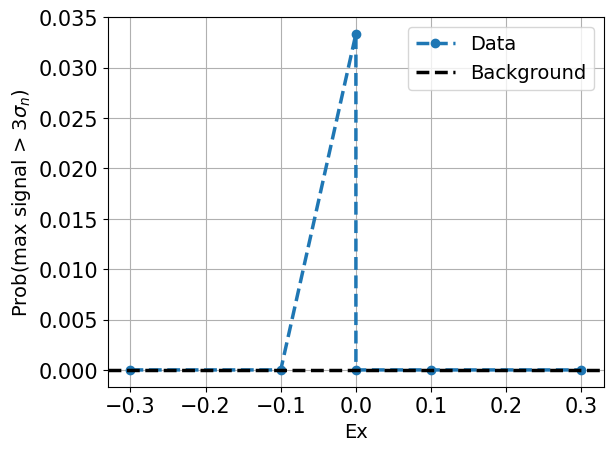

In [25]:
tip_on_files = list_files_in_time_range(data_dir, 
                                        name='RFPowerSweepDifferentialNAcquisitionTipSwitched', start_time='15:50:00', stop_time='20:00:00')

tip_off_files = [
    'data/experiment_07232026/RFPowerSweepDifferentialNAcquisitionTipSwitched_22-33-02.h5'
]
plot_Prob_vs_var(tip_on_files, tip_off_files, data_dir=home_dir, var='Ex', xlabel='Ex', sigma_cutoff=3
                )

In [40]:
np.sqrt(dBm_to_W(4)/dBm_to_W(5))*176.31

157.13645290236067

In [22]:
import ipywidgets as widgets
from IPython.display import display, clear_output
def plot_peak_timing_across_var(tip_on_files, data_dir, var='t_load', fix_xlim=False):
    """
    Plots histograms of detected power for Tip-On and Tip-Off datasets across a specified variable.

    Parameters:
    - tip_on_files: List of file paths for Tip-On datasets.
    - tip_off_files: List of file paths for Tip-Off datasets.
    - data_dir: Base directory where the data files are located.
    - var: The variable to use for mapping datasets (default is 't_load').
    - fix_xlim: Boolean (default False). If True, the x-axis limits initialize as locked 
                to the global min and max power values across all scanned datasets.
    """

    on_map = {}
    off_map = {}

    # We will track the absolute minimum and maximum power values in nW across all datasets
    global_x_min = float('inf')
    global_x_max = float('-inf')

    print(f"Scanning datasets for {var} and calculating global x-limits...")
    
    # Scan Tip-On files
    for f in tip_on_files:
        try:
            f_data = load_h5_data(f, base=data_dir)
            t_val = f_data.get(f'{var}', None)
            if t_val is not None:
                on_map[t_val] = f
                
            # Convert values to nW to find global limits
            data = f_data.get('all_meas', [])
            if len(data) > 0:
                p_nw_vals = dBm_to_W(np.concatenate(data, axis=0)) * 1e9
                global_x_min = min(global_x_min, np.min(p_nw_vals))
                global_x_max = max(global_x_max, np.max(p_nw_vals))
        except Exception as e:
            print(f"Skipping Tip-On file {f}: {e}")


    unique_t_loads = sorted(list(on_map.keys()))
    print(f"Scan complete. Found {len(unique_t_loads)} valid {var} configurations.")

    # Calculate padding for fixed limits
    has_global_limits = (global_x_min != float('inf') and global_x_max != float('-inf'))
    if has_global_limits:
        x_range = global_x_max - global_x_min
        padding = x_range * 0.05 if x_range > 0 else 1.0
        global_x_min -= padding
        global_x_max += padding
    else:
        global_x_min, global_x_max = 0, 10 # Fallbacks

    # 2. Setup UI elements (Dropdown, Buttons, Checkbox)
    t_load_dropdown = widgets.Dropdown(
        options=unique_t_loads,
        value=unique_t_loads[0] if unique_t_loads else None,
        description=f'{var}:'
    )

    btn_prev = widgets.Button(
        description='Prev',
        button_style='info',     
        icon='arrow-left'        
    )

    btn_next = widgets.Button(
        description='Next',
        button_style='primary',  
        icon='arrow-right'       
    )

    fix_xlim_checkbox = widgets.Checkbox(
        value=fix_xlim,
        description='Fix X-Axis Limits',
        disabled=not has_global_limits,
        indent=False
    )

    plot_output = widgets.Output()

    # 3. Plotting logic wrapped in an output handler
    def draw_plot(change=None):
        t_load = t_load_dropdown.value
        
        with plot_output:
            clear_output(wait=True)
            
            if t_load is None:
                print(f"No {var} configured.")
                return

            on_file_path = on_map.get(t_load)
            off_file_path = off_map.get(t_load) or (list(off_map.values())[0] if off_map else None)

            if not on_file_path:
                print(f"No Tip-On file found for {var}: {t_load}")
                return

            # Load file data
            file = load_h5_data(on_file_path, base=data_dir)
            data = file['all_meas']
            print(np.shape(data))
            
            # Calculate Power in nW for Tip-On
            t_seq_end = file['t_data']
            x_data = t_seq_end * 1e3
            t_axis = np.linspace(0, x_data, len(data[0])) 
            P_nW = np.array([t_axis[np.argmax(data_i)] for data_i in data])
            bin_size = 0.01

            # Plotting Setup
            fig, ax = plt.subplots(figsize=(7, 4))

            # 1. Plot Tip On Histogram
            counts, bin_edges = np.histogram(P_nW, bins=int((max(P_nW) - min(P_nW)) / bin_size))
            ax.bar(
                bin_edges[:-1], 
                counts / np.sum(counts), 
                width=np.diff(bin_edges),
                label='Tip on',
                align='edge', 
                alpha=0.6,
                color='blue'
            )

            # 2. Plot Tip Off Histogram (if background file exists)
            if off_file_path:
                file2 = load_h5_data(off_file_path, base=data_dir)
                data2 = file2['all_meas']
                P_nW_background = dBm_to_W(np.concatenate(data2, axis=0)) * 1e9

                counts_bg, bin_edges_bg = np.histogram(
                    P_nW_background, 
                    bins=int((max(P_nW_background) - min(P_nW_background)) / bin_size)
                )
                ax.bar(
                    bin_edges_bg[:-1], 
                    counts_bg / np.sum(counts_bg), 
                    width=np.diff(bin_edges_bg),
                    label='Tip off',
                    align='edge', 
                    alpha=0.6,
                    color='orange'
                )

            # Apply locked limits if requested
            if fix_xlim_checkbox.value:
                ax.set_xlim(global_x_min, global_x_max)

            # Graph configurations
            ax.set_yscale('log')
            ax.set_title(f"Histogram of Detected Power | {var} = {t_load}")
            ax.set_xlabel('Detected Power (nW)') 
            ax.set_ylabel('Probability Density / 0.01nW bin')
            ax.grid(True)
            ax.legend()
            plt.show()

    # 4. Define event behaviors for Slider/Buttons
    def on_dropdown_change(change):
        draw_plot(change['new'])

    def on_next_clicked(b):
        opts = t_load_dropdown.options
        if not opts: return
        idx = opts.index(t_load_dropdown.value)
        t_load_dropdown.value = opts[idx + 1] if idx < len(opts) - 1 else opts[0]

    def on_prev_clicked(b):
        opts = t_load_dropdown.options
        if not opts: return
        idx = opts.index(t_load_dropdown.value)
        t_load_dropdown.value = opts[idx - 1] if idx > 0 else opts[-1]

    # Link actions to the widgets
    t_load_dropdown.observe(on_dropdown_change, names='value')
    # Automatically redraw when the user switches fixed limits
    fix_xlim_checkbox.observe(lambda change: draw_plot(), names='value')
    
    btn_next.on_click(on_next_clicked)
    btn_prev.on_click(on_prev_clicked)

    # 5. Pack layouts and display
    controls = widgets.HBox([btn_prev, t_load_dropdown, btn_next, fix_xlim_checkbox])
    ui = widgets.VBox([controls, plot_output])

    display(ui)

    # Render the first plot
    if t_load_dropdown.value is not None:
        draw_plot(t_load_dropdown.value)

In [60]:
l = list_files_in_time_range(data_dir, 
                                       name='RFPowerSweepDifferentialNAcquisitionTipSwitched', start_time=None, stop_time=None)
l.sort()
l

['/home/electron/data/experiment_07232026/RFPowerSweepDifferentialNAcquisitionTipSwitched_00-34-19.h5',
 '/home/electron/data/experiment_07232026/RFPowerSweepDifferentialNAcquisitionTipSwitched_01-02-00.h5',
 '/home/electron/data/experiment_07232026/RFPowerSweepDifferentialNAcquisitionTipSwitched_01-29-44.h5',
 '/home/electron/data/experiment_07232026/RFPowerSweepDifferentialNAcquisitionTipSwitched_02-03-59.h5',
 '/home/electron/data/experiment_07232026/RFPowerSweepDifferentialNAcquisitionTipSwitched_02-31-46.h5',
 '/home/electron/data/experiment_07232026/RFPowerSweepDifferentialNAcquisitionTipSwitched_03-07-32.h5',
 '/home/electron/data/experiment_07232026/RFPowerSweepDifferentialNAcquisitionTipSwitched_03-35-27.h5',
 '/home/electron/data/experiment_07232026/RFPowerSweepDifferentialNAcquisitionTipSwitched_04-12-15.h5',
 '/home/electron/data/experiment_07232026/RFPowerSweepDifferentialNAcquisitionTipSwitched_04-40-21.h5',
 '/home/electron/data/experiment_07232026/RFPowerSweepDifferenti

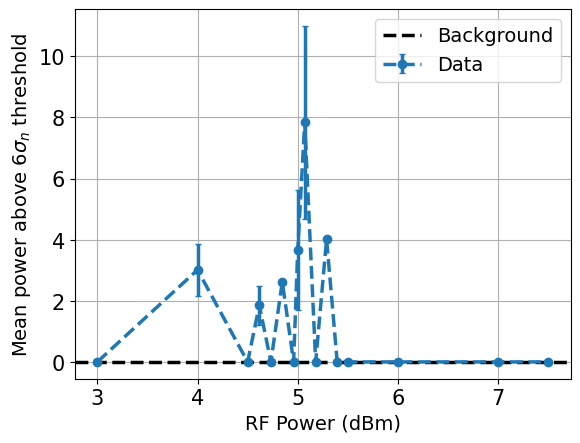

In [62]:
# tip_on_files = list_files_in_time_range(data_dir, 
                                        # name='RFPowerSweepDifferentialNAcquisitionTipSwitched', start_time='05:30:00', stop_time='10:30:00')
tip_on_files = ['/home/electron/data/experiment_07232026/RFPowerSweepDifferentialNAcquisitionTipSwitched_21-36-32.h5',
 '/home/electron/data/experiment_07232026/RFPowerSweepDifferentialNAcquisitionTipSwitched_21-56-47.h5',
 '/home/electron/data/experiment_07232026/RFPowerSweepDifferentialNAcquisitionTipSwitched_22-15-30.h5',
 '/home/electron/data/experiment_07232026/RFPowerSweepDifferentialNAcquisitionTipSwitched_22-33-02.h5',
 '/home/electron/data/experiment_07232026/RFPowerSweepDifferentialNAcquisitionTipSwitched_22-50-11.h5',
 '/home/electron/data/experiment_07232026/RFPowerSweepDifferentialNAcquisitionTipSwitched_23-36-50.h5',
                '/home/electron/data/experiment_07232026/RFPowerSweepDifferentialNAcquisitionTipSwitched_00-34-19.h5',
 '/home/electron/data/experiment_07232026/RFPowerSweepDifferentialNAcquisitionTipSwitched_01-02-00.h5',
 '/home/electron/data/experiment_07232026/RFPowerSweepDifferentialNAcquisitionTipSwitched_01-29-44.h5',
 '/home/electron/data/experiment_07232026/RFPowerSweepDifferentialNAcquisitionTipSwitched_02-03-59.h5',
 '/home/electron/data/experiment_07232026/RFPowerSweepDifferentialNAcquisitionTipSwitched_02-31-46.h5',
 '/home/electron/data/experiment_07232026/RFPowerSweepDifferentialNAcquisitionTipSwitched_03-07-32.h5',
 '/home/electron/data/experiment_07232026/RFPowerSweepDifferentialNAcquisitionTipSwitched_03-35-27.h5',
 '/home/electron/data/experiment_07232026/RFPowerSweepDifferentialNAcquisitionTipSwitched_04-12-15.h5',
 '/home/electron/data/experiment_07232026/RFPowerSweepDifferentialNAcquisitionTipSwitched_04-40-21.h5',
 '/home/electron/data/experiment_07232026/RFPowerSweepDifferentialNAcquisitionTipSwitched_05-08-19.h5']

tip_off_files = [
    'data/experiment_07232026/RFPowerSweepDifferentialNAcquisitionTipSwitched_10-35-24.h5'
]
plot_peak_power_vs_var(tip_on_files, tip_off_files, data_dir=home_dir, var='P_detect', xlabel='RF Power (dBm)', sigma_cutoff=6)

In [23]:
tip_on_files = list_files_in_time_range(data_dir, 
                                        name='RFPowerSweepDifferentialNAcquisitionTipSwitched', start_time=None, stop_time='05:30:00')
plot_peak_timing_across_var(tip_on_files, '', var='P_detect') 

Scanning datasets for P_detect and calculating global x-limits...
Scan complete. Found 10 valid P_detect configurations.
